# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [187]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

In [208]:
# ⭐ helper functions with descriptions ⭐ probably redundant for functionality but useful for understanding what's going on
def convert_to_proper_format(array: np.ndarray) -> np.ndarray:
    """ Convert the image from BGR to RGB or RGBA or leave it as grayscale """
    print(img_bgr.shape) # first check the shape of the image

    if array.ndim == 3 and array.shape[2] == 4:
        print('converting BGRA to RGBA')
        return cv2.cvtColor(array, cv2.COLOR_BGRA2RGBA)
    elif array.ndim == 3 and array.shape[2] == 3:
        print('converting BGR to RGB')
        return cv2.cvtColor(array, cv2.COLOR_BGR2RGB)
    else:
        print('grayscale image')
        return array

eps = 1e-8

(846, 1500, 3)
converting BGR to RGB


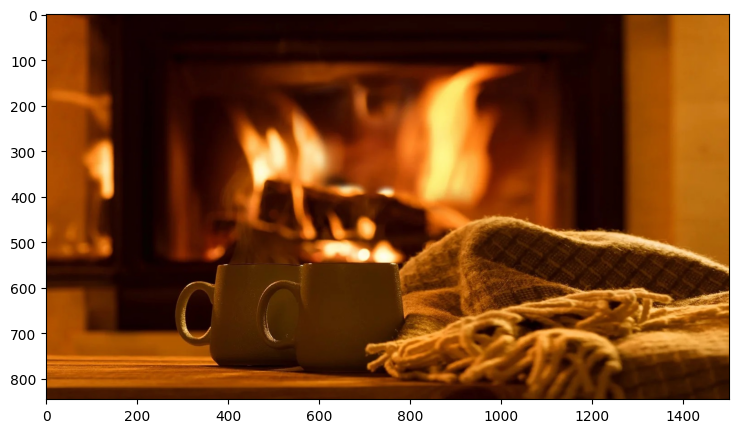

In [189]:
# img_bgr = cv2.imread('../data/sea.jpg') # - Original image
# img_bgr = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg') # - beautiful landscape
# img_bgr = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg') # - another beautiful landscape
img_bgr = cv2.imread('../data/cocoa+fireside.jpg') # Let's work with this one

img = convert_to_proper_format(img_bgr)

plt.imshow(img)


### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x2350ab766d0>)

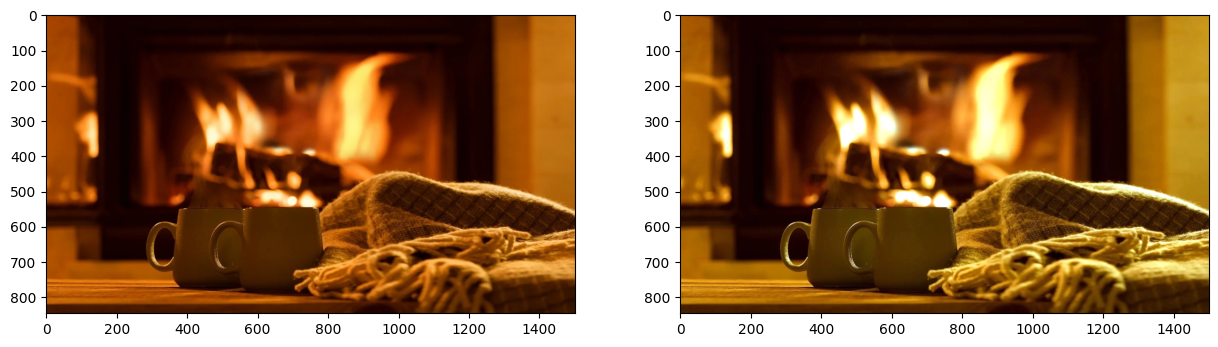

In [190]:
# Define white patch and the coefficients

# FOR ../data/cocoa+fireside.jpg
# row, col = 690, 525 # the best white-patch candidate according to ChatGPT - actually not the best 🤷‍♂️
# row, col = 220, 1392 # right wall middle
# row, col = 1, 1383 # right wall top
# row, col = 319, 869 # fireplace
row, col = 609, 479 # a reflection on the handle of a mug. no artifacts. IMHO Winner 👑
white = img[row, col, :]


coeffs = 255.0/white # kr, kg, kb

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

(846, 1500, 3)
converting BGR to RGB
mean_r 85.30767286869518 mean_g 91.61271587171052 mean_b 93.62359797605994
kr 1.097481608390808 kg 1.0219497680664062 kb 1.0


(<Axes: >, <matplotlib.image.AxesImage at 0x23526efed90>)

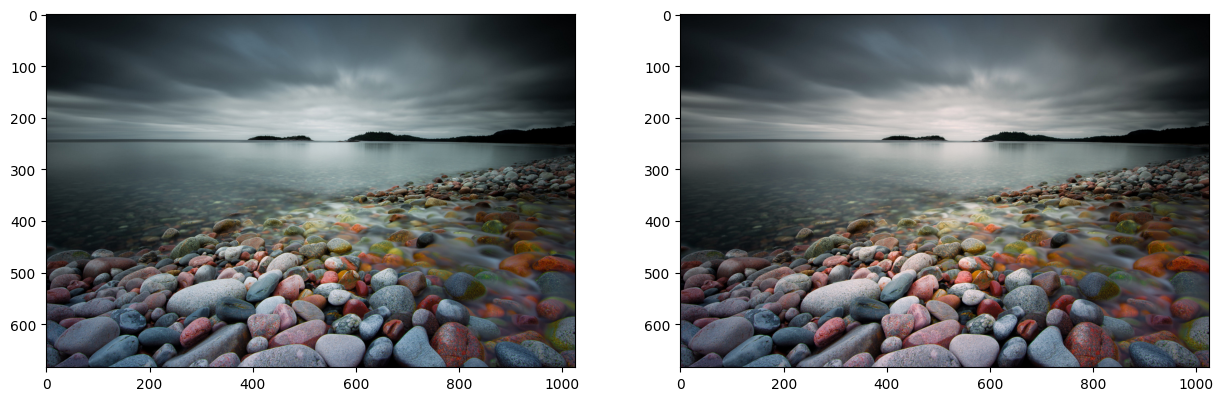

In [224]:
# Load your image
# img = cv2.imread('../data/sea.jpg')
# img = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg')
img = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg')
img = convert_to_proper_format(img)

# Compute the mean values for all three colour channels (red, green, blue)
mean_r = img[..., 0].mean()
mean_g = img[..., 1].mean()
mean_b = img[..., 2].mean()
print('mean_r', mean_r, 'mean_g', mean_g, 'mean_b', mean_b)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1.
means = np.array([mean_r, mean_g, mean_b], dtype=np.float32)
idx_max = int(np.argmax(means)) # automatically find the index of the max mean value (1 approach for different images)

L = means[idx_max] # set the largest mean value to L
den = np.clip(means, eps, None) # avoid division by zero
gains = L / den # compute the gains
gains[means.argmax()] = 1.0 # set the gain of the brightest channel to 1.0
kr, kg, kb = gains.tolist() # unpack the gains
print('kr', kr, 'kg', kg, 'kb', kb) # print the coefficients we will use for balancing

# Apply color balancing and generate the balanced image
balanced = np.clip(
    img.astype(np.float32) * np.array([kr, kg, kb], dtype=np.float32)[None, None, :],
    0, 255
).astype(np.uint8)

# Show the original and the balanced image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

(846, 1500, 3)
converting BGR to RGB
max before: 252 246 254
gains [1.0119047 1.0365853 1.003937 ]
max after: 254.99998 254.99998 255.0


(<Axes: >, <matplotlib.image.AxesImage at 0x2352995f250>)

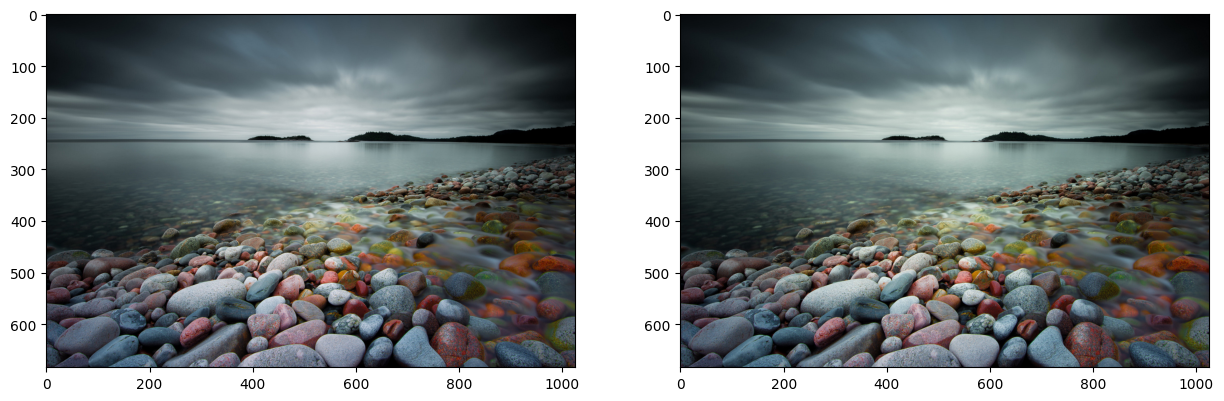

In [229]:
# Load your image
# img = cv2.imread('../data/kenji-yamamura-photographer-6329.jpg')
img = cv2.imread('../data/Canada-lake-Ontario-clouds_sm.jpg')
# img = cv2.imread('../data/cocoa+fireside.jpg')
img = convert_to_proper_format(img)

# Compute the maximum values for all three colour channels (red, green, blue)
max_r = img[..., 0].max()
max_g = img[..., 1].max()
max_b = img[..., 2].max()
print("max before:", max_r, max_g, max_b)

M = max(max_r, max_g, max_b) # the maximum of the maximums
# ⭐ alternative way to compute the gains ⭐
# gains = np.array([M/(max_r+eps), M/(max_g+eps), M/(max_b+eps)], dtype=np.float32) # compute the gains
gains = 255.0 / (np.array([max_r, max_g, max_b], dtype=np.float32) + eps) # compute the gains, avoiding division by zero, convert to float32
print('gains', gains)
print("max after:", max_r * gains[0], max_g * gains[1], max_b * gains[2]) # check the maximum values after balancing

# Apply scale-by-max balancing and generate the balanced image
img_f = img.astype(np.float32)
balanced = img_f * gains[None, None, :]     # broadcast per channel
balanced = np.clip(balanced, 0, 255).astype(np.uint8) # clip and convert back to uint8

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)